К-ближайших соседей (K-Nearest Neighbors или просто KNN) — алгоритм классификации и регрессии, основанный на гипотезе компактности, которая предполагает, что расположенные близко друг к другу объекты в пространстве признаков имеют схожие значения целевой переменной или принадлежат к одному классу.

Принцип работы KNN
Алгоритм строится следующим образом:

1) сначала вычисляется расстояние между тестовым и всеми обучающими образцами;

2) далее из них выбирается k-ближайших образцов (соседей), где число k задаётся заранее;

3) итоговым прогнозом среди выбранных k-ближайших образцов будет мода в случае классификации и среднее арифметическое в случае регрессии;

4) предыдущие шаги повторяются для всех тестовых образцов.



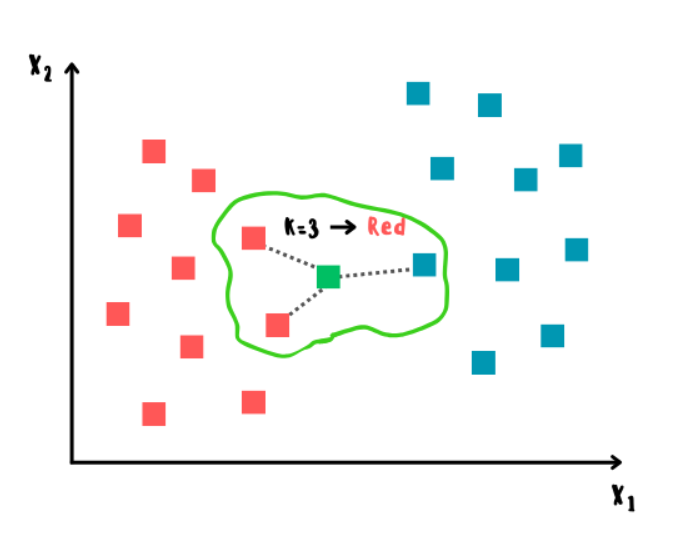

Существует множество метрик для вычисления расстояния между объектами, среди которых наиболее популярными являются следующие:

Евклидово расстояние — это наиболее простая и общепринятая метрика, которая определяется как длина отрезка между двумя объектами a и b в пространстве с nпризнаками

Манхэттенское расстояние — метрика, которая определяется как сумма модулей разностей координат двух точек в пространстве между двумя объектами a и b с n признаками

In [2]:
 # Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import decomposition
from sklearn import datasets

Изменение датасета Ирисы

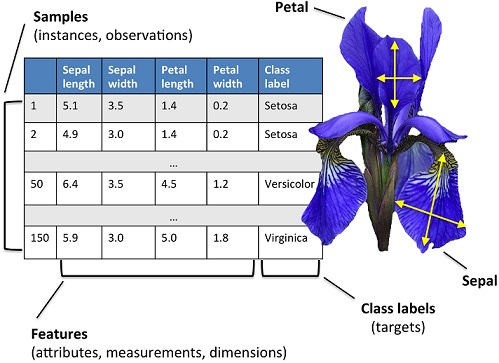

In [3]:
 # Загрузка данных
centers = [[1, 1], [-1, -1], [1, -1]]
iris = datasets.load_iris()
X = iris.data
y = iris.target

In [4]:
X, y

(array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
        [5

In [5]:
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [6]:
iris.target.shape

(150,)

In [7]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [8]:
# Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

# Загружаем датасет
iris = load_iris()

# Создаем DataFrame для удобства работы
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
iris_df['numbers'] = iris.target

# Посмотрим на первые 5 строк датасета
print(iris_df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  numbers  
0  setosa        0  
1  setosa        0  
2  setosa        0  
3  setosa        0  
4  setosa        0  


In [9]:
# Базовый статистический анализ
print(iris_df.describe())

# Проверка наличия пропущенных значений
print(iris_df.isnull().sum())

# Распределение классов
print(iris_df['species'].value_counts())



       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)     numbers  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
pet

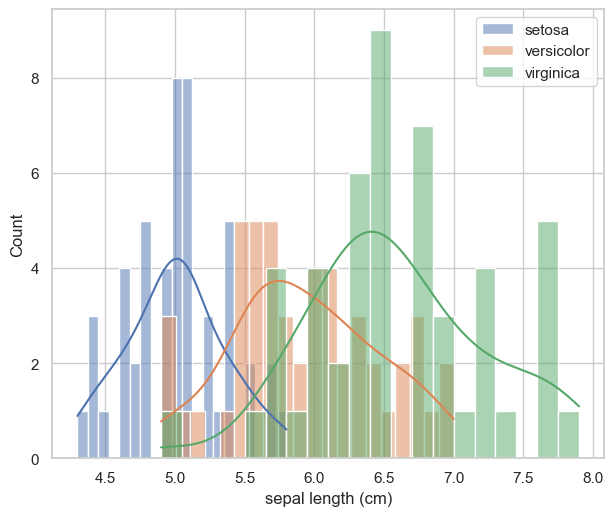

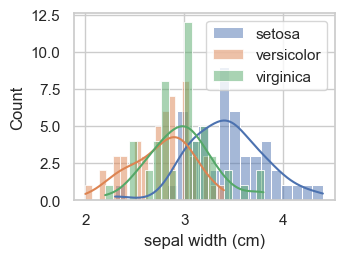

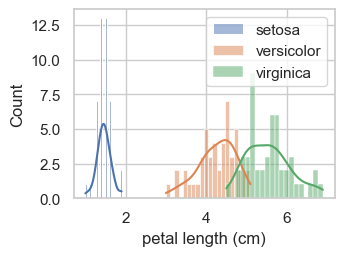

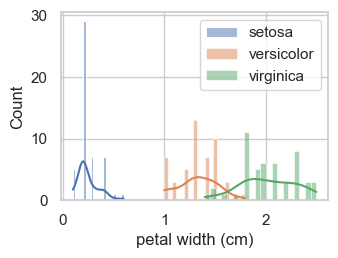

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настраиваем стиль визуализации
sns.set_theme(style="whitegrid")

# Создаем гистограммы для каждого признака
plt.figure(figsize=(12, 10))
for i, feature in enumerate(iris.feature_names):
  plt.subplot(2, 2, i+1)
  for species in iris.target_names:
    subset = iris_df[iris_df['species'] == species]
    sns.histplot(subset[feature], label=species, kde=True, bins=20)
    plt.xlabel(feature)
    plt.legend()
    plt.tight_layout()
  plt.show()

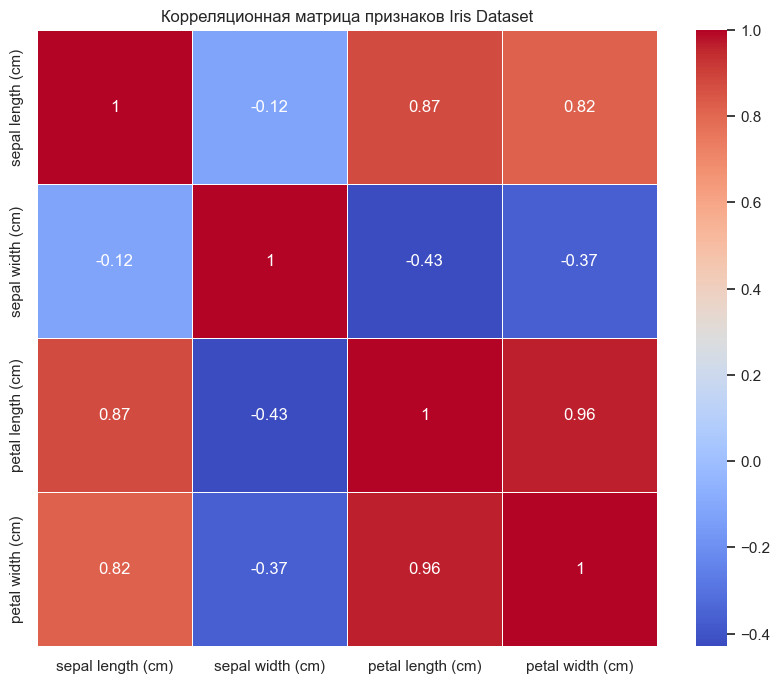

In [11]:
# Корреляционная тепловая карта
plt.figure(figsize=(10, 8))
iris_df.drop('numbers', axis=1, inplace=True)
corr = iris_df.drop('species', axis=1).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Корреляционная матрица признаков Iris Dataset")
plt.show()

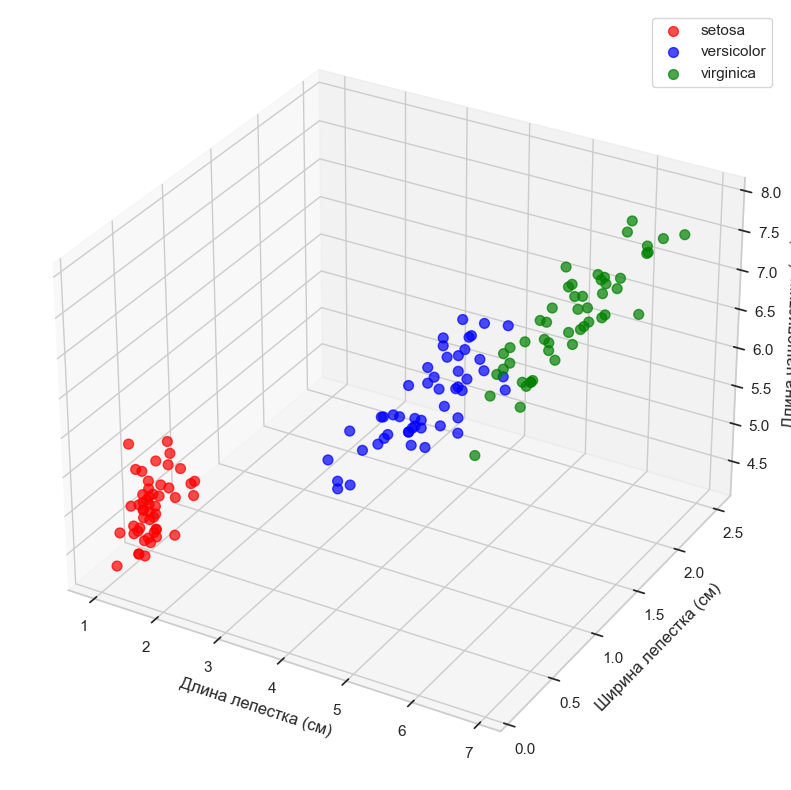

In [12]:
# 3D визуализация
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Выбираем три наиболее информативных признака
x = iris_df['petal length (cm)']
y = iris_df['petal width (cm)']
z = iris_df['sepal length (cm)']

# Цвета для разных классов
colors = {'setosa': 'red', 'versicolor': 'blue', 'virginica': 'green'}

# Наносим точки на график
for species in iris.target_names:
  idx = iris_df['species'] == species
  ax.scatter(x[idx], y[idx], z[idx], c=colors[species], label=species, s=50, alpha=0.7)

ax.set_xlabel('Длина лепестка (см)')
ax.set_ylabel('Ширина лепестка (см)')
ax.set_zlabel('Длина чашелистика (см)')
ax.legend()
plt.show()

In [13]:

# Загрузка данных
centers = [[1, 1], [-1, -1], [1, -1]]
iris = datasets.load_iris()
X = iris.data
y = iris.target

In [14]:
res_eig = np.linalg.eig(np.dot(X.T, X))

In [15]:
res_eig[0]

array([9.20830507e+03, 3.15454317e+02, 1.19780429e+01, 3.55257020e+00])

In [16]:
print(*np.linalg.svd(np.dot(X.T, X)), sep='\n')

[[-0.75110816 -0.2841749   0.50215472  0.32081425]
 [-0.38008617 -0.5467445  -0.67524332 -0.31725607]
 [-0.51300886  0.70866455 -0.05916621 -0.48074507]
 [-0.16790754  0.34367081 -0.53701625  0.75187165]]
[9.20830507e+03 3.15454317e+02 1.19780429e+01 3.55257020e+00]
[[-0.75110816 -0.38008617 -0.51300886 -0.16790754]
 [-0.2841749  -0.5467445   0.70866455  0.34367081]
 [ 0.50215472 -0.67524332 -0.05916621 -0.53701625]
 [ 0.32081425 -0.31725607 -0.48074507  0.75187165]]


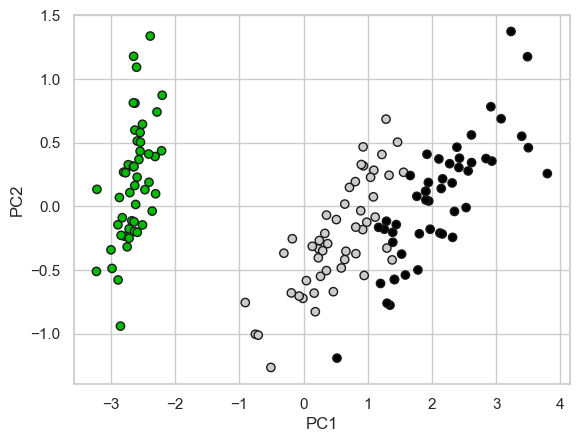

In [17]:
 # Преобразование данных датасета Iris, уменьшающее размерность до 2
pca = decomposition.PCA(n_components=3)
pca.fit(X)
X = pca.transform(X)
y = np.choose(y, [1, 2, 0]).astype(np.float32)
plt.clf()
plt.cla()
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.nipy_spectral, edgecolor='k')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [18]:
X, y

(array([[-2.68412563,  0.31939725, -0.02791483],
        [-2.71414169, -0.17700123, -0.21046427],
        [-2.88899057, -0.14494943,  0.01790026],
        [-2.74534286, -0.31829898,  0.03155937],
        [-2.72871654,  0.32675451,  0.09007924],
        [-2.28085963,  0.74133045,  0.16867766],
        [-2.82053775, -0.08946138,  0.25789216],
        [-2.62614497,  0.16338496, -0.02187932],
        [-2.88638273, -0.57831175,  0.02075957],
        [-2.6727558 , -0.11377425, -0.19763272],
        [-2.50694709,  0.6450689 , -0.07531801],
        [-2.61275523,  0.01472994,  0.10215026],
        [-2.78610927, -0.235112  , -0.20684443],
        [-3.22380374, -0.51139459,  0.06129967],
        [-2.64475039,  1.17876464, -0.15162752],
        [-2.38603903,  1.33806233,  0.2777769 ],
        [-2.62352788,  0.81067951,  0.13818323],
        [-2.64829671,  0.31184914,  0.02666832],
        [-2.19982032,  0.87283904, -0.12030552],
        [-2.5879864 ,  0.51356031,  0.21366517],
        [-2.31025622

Разобьем данные на тренировочный и тестовый датасеты и для простоты реализации алгоритма объединим массивы признаков объектов и метки их классов, чтобы было понятно, к какому классу относится каждый объект.

In [21]:
y.shape

(150,)

In [78]:
from sklearn.model_selection import train_test_split

SIZE = 40

x_train, x_test, y_train, y_test = train_test_split(X[:, :],
                                                    y,
                                                    train_size=SIZE,
                                                    random_state=541) # random_state - для воспроизводимости

print(f'X_train shape: {x_train.shape}, y_train shape: {y_train.shape},\n'
      f'X_test shape: {x_test.shape}, y_test shape: {y_test.shape}')

X_train shape: (40, 3), y_train shape: (40,),
X_test shape: (110, 3), y_test shape: (110,)


In [79]:
import numpy as np

x_train_concat = np.concatenate((x_train, y_train.reshape(SIZE, 1)), axis=1)
x_test_concat = np.concatenate((x_test, y_test.reshape(150-SIZE, 1)), axis=1)
print(f'X_train shape: {x_train_concat.shape},\n'
      f'X_test shape: {x_test_concat.shape}')

X_train shape: (40, 4),
X_test shape: (110, 4)


In [80]:
pd.DataFrame(x_train_concat).head(5)

,0,1,2,3
0,0.588006,-0.484287,0.444433,2.0
1,2.159438,-0.217278,0.208763,0.0
2,0.045227,-0.583834,-0.235002,2.0
3,0.357888,-0.068925,-0.229854,2.0
4,0.464800,-0.670712,-0.024307,2.0


In [81]:
import math

def euclidean_distance(data1, data2):
    distance = 0
    for i in range (len(data1) - 1):
        distance += (data1[i] - data2[i]) ** 2
    return math.sqrt(distance)

Выбираем норму

$\lVert x \rVert_1 = \sum\limits_{i=1}^n \lvert x_i \rvert$

$\lVert x \rVert_2 = \sqrt{\sum\limits_{i=1}^n x_i^2}$

$\lVert x \rVert_p = \sqrt[p]{\sum\limits_{i=1}^n x_i^p}$

$\lVert x \rVert_\infty = \max\limits_i \lvert x_i \rvert$

In [82]:
norms = {"Первая" : 1, "Вторая" : 2, "Третья" : 3, "Бесконечная" : np.inf}


Вычислим расстояния до всех точек обучающей выборки и отберем  k  соседей (то есть тех, расстояния до которых минимальны).

In [83]:
def get_neighbors(train, test, norm, k=1):
    distances = [(train[i][-1], np.linalg.norm(train[i][:-1] - test[:-1], ord=norm))
                  for i in range (len(train))]
    distances.sort(key=lambda elem: elem[1])

    neighbors = [distances[i][0] for i in range (k)]
    return neighbors

Теперь получим прогноз на основе классов соседей. Посчитаем, сколько объектов каждого класса присутствует среди  k  ближайших к целевому, и затем причислим его к тому классу, экземпляров которого больше всего.

In [84]:
def prediction(neighbors):
    count = {}
    for instance in neighbors:
        if instance in count:
            count[instance] +=1
        else :
            count[instance] = 1
    target = max(count.items(), key=lambda x: x[1])[0]
    return target

Напишем последнюю функцию для оценки точности прогнозов - это просто отношение верных прогнозов к общему количеству прогнозов.

In [85]:
def accuracy(test, test_prediction):
    correct = 0
    for i in range (len(test)):
        if test[i][-1] == test_prediction[i]:
            correct += 1
    return (correct / len(test))

Посмотрим, как работает наш алгоритм.

In [86]:
predictions = []
for x in range (len(x_test_concat)):
    neighbors = get_neighbors(x_train_concat, x_test_concat[x], norms['Первая'], k=5)
    result = prediction(neighbors)
    predictions.append(result)
acc = accuracy(x_test_concat, predictions)
print(f'Accuracy: {acc}')

Accuracy: 0.9363636363636364


In [87]:
res_acc = []
for knbr in range(1, 21):
    predictions = []
    for x in range (len(x_test_concat)):
        neighbors = get_neighbors(x_train_concat, x_test_concat[x], norms['Третья'], k=knbr)
        result = prediction(neighbors)
        predictions.append(result)
    acc = accuracy(x_test_concat, predictions)
    res_acc.append([knbr, acc])

In [88]:
res_acc

[[1, 0.9181818181818182],
 [2, 0.9181818181818182],
 [3, 0.9090909090909091],
 [4, 0.9363636363636364],
 [5, 0.9272727272727272],
 [6, 0.9363636363636364],
 [7, 0.9363636363636364],
 [8, 0.9363636363636364],
 [9, 0.9272727272727272],
 [10, 0.9181818181818182],
 [11, 0.9272727272727272],
 [12, 0.9272727272727272],
 [13, 0.9181818181818182],
 [14, 0.9181818181818182],
 [15, 0.9090909090909091],
 [16, 0.9090909090909091],
 [17, 0.9],
 [18, 0.9090909090909091],
 [19, 0.5272727272727272],
 [20, 0.5272727272727272]]

импортируем библиотечную версию алгоритма.

In [89]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)

In [90]:
knn_model = knn.fit(x_train, y_train)

In [91]:
knn_predictions = knn.predict(x_test)
knn_predictions

array([0., 1., 2., 1., 2., 2., 1., 2., 1., 0., 2., 2., 0., 1., 2., 2., 0.,
       0., 1., 1., 1., 1., 0., 2., 2., 0., 1., 2., 2., 1., 1., 1., 2., 2.,
       1., 1., 1., 0., 2., 2., 0., 0., 2., 2., 2., 1., 0., 2., 2., 0., 2.,
       0., 1., 1., 0., 0., 2., 2., 1., 2., 0., 1., 1., 0., 2., 2., 1., 1.,
       0., 1., 1., 0., 1., 0., 2., 0., 0., 0., 1., 0., 1., 2., 0., 1., 0.,
       0., 1., 0., 1., 1., 1., 1., 0., 1., 2., 1., 0., 2., 2., 2., 0., 1.,
       2., 1., 1., 0., 0., 1., 2., 2.], dtype=float32)

In [92]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, knn_predictions)
print(f'Accuracy: {acc}')

Accuracy: 0.9272727272727272


In [93]:
mod_acc = []
for knbr in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=knbr)
    knn_model = knn.fit(x_train, y_train)
    knn_predictions = knn.predict(x_test)
    acc = accuracy_score(y_test, knn_predictions)
    mod_acc.append((knbr, acc))

In [94]:
mod_acc

[(1, 0.9181818181818182),
 (2, 0.9363636363636364),
 (3, 0.9090909090909091),
 (4, 0.9363636363636364),
 (5, 0.9272727272727272),
 (6, 0.9363636363636364),
 (7, 0.9363636363636364),
 (8, 0.9363636363636364),
 (9, 0.9272727272727272),
 (10, 0.9272727272727272),
 (11, 0.9181818181818182),
 (12, 0.9363636363636364),
 (13, 0.9363636363636364),
 (14, 0.9272727272727272),
 (15, 0.9181818181818182),
 (16, 0.9181818181818182),
 (17, 0.9090909090909091),
 (18, 0.9090909090909091),
 (19, 0.5272727272727272),
 (20, 0.5363636363636364)]

In [95]:
max(mod_acc, key=lambda x:x[1])

(2, 0.9363636363636364)